In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Footprints (see analysis code for calculation)
atf1_footprint_path = "../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/representative_hoco_motif/raw_signals/ATF1_raw_windows.csv"
atf2_footprint_path = "../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/representative_hoco_motif/raw_signals/ATF2_raw_windows.csv"

## Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data Loading

In [4]:
# Load ATF1 and ATF2 footprint data
atf1_fp = pd.read_csv(atf1_footprint_path)
atf2_fp = pd.read_csv(atf2_footprint_path)

## Helper Functions

In [5]:
# Get available positional columns in dataframe
def _pos_cols_in(df: pd.DataFrame, rng):
    # Build column names like pos_-100 ... pos_100
    cols = [f"pos_{i}" for i in rng]
    
    # Keep only columns that actually exist in the dataframe
    return [c for c in cols if c in df.columns]


# Sort rows based on signal strength and extract the desired window
def _sorted_and_window(df: pd.DataFrame, width: int):
    # Ensure valid window size
    if width < 1:
        raise ValueError("width must be >= 1")

    # Define region used for sorting (central region)
    sort_range = range(-25, 26)
    
    # Define region used for plotting (full window)
    heat_range = range(-width, width + 1)

    # Get columns used for sorting
    sort_cols = _pos_cols_in(df, sort_range)
    if len(sort_cols) == 0:
        raise ValueError("No sorting columns found (expected 'pos_-25'..'pos_25').")

    # Compute total signal in the central region for each row
    sort_sum = df[sort_cols].sum(axis=1)

    # Sort rows by signal strength (descending)
    df_sorted = df.assign(_sum=sort_sum).sort_values("_sum", ascending=False).drop(columns="_sum")

    # Get columns for the full window (used in plotting)
    heat_cols = _pos_cols_in(df_sorted, heat_range)
    if len(heat_cols) == 0:
        raise ValueError(f"No heatmap columns found for width={width}.")

    return df_sorted, heat_cols


# Plot footprint comparison between two samples
def plot_2sample_footprint(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    *,
    top_n: int = 200,
    width: int = 100,
    dropna: bool = False,
    figsize = (3.5, 3.5),
    title = None,
    linewidth: float = 1.5,
    labels = ("Sample 1", "Sample 2"),
):

    # Process sample 1

    # Sort rows and extract relevant columns
    df1_sorted, heat_cols1 = _sorted_and_window(df1, width)

    # Optionally remove rows with missing values in the window
    if dropna:
        df1_sorted = df1_sorted.dropna(subset=heat_cols1)

    # Select top-N strongest rows
    n1 = min(top_n, len(df1_sorted))
    sub1 = df1_sorted.iloc[:n1][heat_cols1]

    # Compute average signal across selected rows
    y1 = sub1.mean(axis=0, skipna=True).to_numpy()

    # Extract x-axis positions from column names
    xs = np.array([int(c.split("_", 1)[1]) for c in heat_cols1], dtype=int)


    # Process sample 2

    # Repeat same processing for second dataset
    df2_sorted, heat_cols2 = _sorted_and_window(df2, width)
    if dropna:
        df2_sorted = df2_sorted.dropna(subset=heat_cols2)

    # Ensure both samples use identical coordinate columns
    if heat_cols2 != heat_cols1:
        raise ValueError("Samples do not have matching pos_-W..pos_W columns.")
    
    # Select top-N rows
    n2 = min(top_n, len(df2_sorted))
    sub2 = df2_sorted.iloc[:n2][heat_cols2]

    # Compute average signal
    y2 = sub2.mean(axis=0, skipna=True).to_numpy()


    # Plot

    fig, ax = plt.subplots(figsize=figsize)

    # Plot both samples
    line1, = ax.plot(xs, y1, lw=linewidth, color="dodgerblue", label=labels[0])
    line2, = ax.plot(xs, y2, lw=linewidth, color="orange", label=labels[1])

    # Add vertical line at motif center (position 0)
    ax.axvline(0, ls="--", alpha=0.2, color="black")

    # Axis labels
    ax.set_xlabel("Distance from motif (bp)", fontsize=16)
    ax.set_ylabel("Mean Signal", fontsize=16, labelpad=0)

    # Optional title
    if title:
        ax.set_title(title)

    # Set x-axis ticks for readability
    ax.set_xticks([-75, -50, -25, 0, 25, 50, 75])
    ax.tick_params(axis="x", labelsize=11)

    # Reverse legend order (swap lines)
    ax.legend(handles=[line2, line1], labels=[labels[1], labels[0]], fontsize=14)

    fig.tight_layout()
    return fig

## Plot

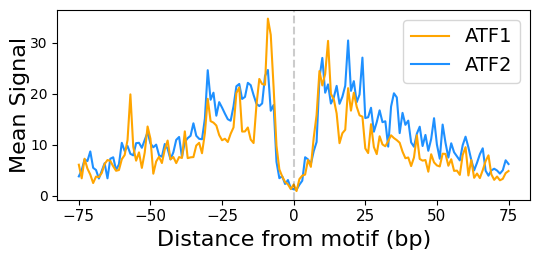

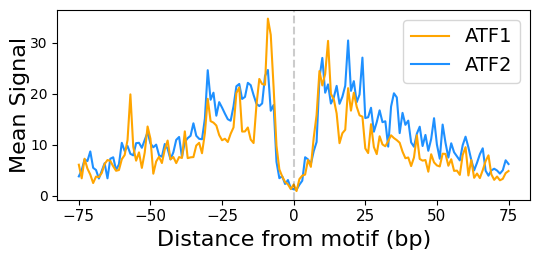

In [6]:
plot_2sample_footprint(atf2_fp, atf1_fp, title="", dropna=False, width=75, top_n=200,
                       figsize = (5.5, 2.7), labels = ("ATF2", "ATF1"))